# Connexion au Google drive

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')
save_path = '/content/drive/MyDrive/Projet_Toubib_AI'
if not os.path.exists(save_path):
    os.makedirs(save_path)

Mounted at /content/drive


# 1. Importation des librairies

In [2]:
import os
import numpy as np
import pandas as pd
import os
import shutil
import random
from glob import glob
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

# Installation et import Ultralytics
!pip install ultralytics
import ultralytics
# vérification des ressources CPU et GPU
ultralytics.checks()

# Modèle
from ultralytics import YOLO

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 42.9/112.6 GB disk)


# 2. Téléchargement du dataset et vérification de l’utilisation GPU

In [ ]:
os.environ['KAGGLE_USERNAME'] = "xxxxxxxxxxx" #==> A cacher
os.environ['KAGGLE_KEY'] = "KGAT_xxxxxxxxxxxxxxxxxxxxxxxxxxxx" #==> A cacher

!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
!mkdir -p dataset_skin
!unzip -q skin-cancer-mnist-ham10000.zip -d dataset_skin

print("Dataset téléchargé")

device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU non trouvé...')
else:
  print('Bravo ! Tu es connecté au GPU : {}'.format(device_name))

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [05:59<00:00, 15.5MB/s]

Dataset téléchargé
Bravo ! Tu es connecté au GPU : /device:GPU:0


# 3. Visualisation et rééquilibrage du dataset

### Avant rééquilibrage

/tmp/ipykernel_717/3770081403.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='viridis')


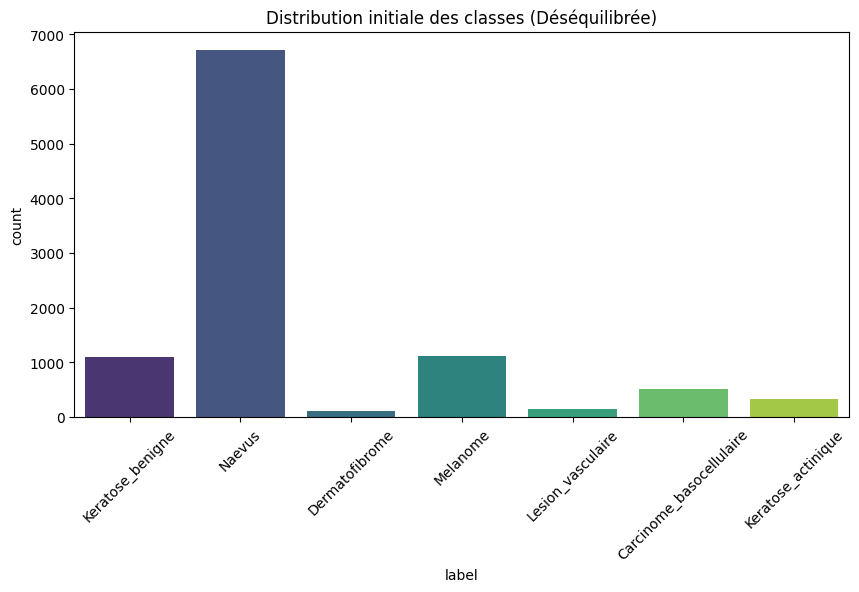

Entraînement : 37590 images
Validation : 992 images
Test final : 1002 images


In [4]:
# Chargement des data
df = pd.read_csv('dataset_skin/HAM10000_metadata.csv')

# Mapping des dossiers
image_paths = {os.path.basename(x).split('.')[0]: x
               for x in glob('dataset_skin/HAM10000_images_part_1/*.jpg') +
                        glob('dataset_skin/HAM10000_images_part_2/*.jpg')}
df['path'] = df['image_id'].map(image_paths)

# Distribution du dataset en 7 classes
lesion_type_dict = {'nv': 'Naevus',
                    'mel': 'Melanome',
                    'bkl': 'Keratose_benigne',
                    'bcc': 'Carcinome_basocellulaire',
                    'akiec': 'Keratose_actinique',
                    'vasc': 'Lesion_vasculaire',
                    'df': 'Dermatofibrome'}
df['label'] = df['dx'].map(lesion_type_dict)

# Visualisation avant rééquilibrage
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='label', palette='viridis')
plt.xticks(rotation=45)
plt.title("Distribution initiale des classes (Déséquilibrée)")
plt.show()

# Split initial (80/10/10)
temp_df, test_df = train_test_split(df, test_size=0.10, random_state=42, stratify=df['dx'])
train_df, val_df = train_test_split(temp_df, test_size=0.11, random_state=42, stratify=temp_df['dx'])

# Rééquilibrage des classes
max_size = train_df['dx'].value_counts().max()
lst = [train_df[train_df['dx'] == cls].sample(max_size, replace=True) for cls in train_df['dx'].unique()]
train_df_balanced = pd.concat(lst, axis=0).sample(frac=1).reset_index(drop=True)

print(f"Entraînement : {len(train_df_balanced)} images")
print(f"Validation : {len(val_df)} images")
print(f"Test final : {len(test_df)} images")

### Après rééquilibrage

/tmp/ipykernel_717/1601076086.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=train_df_balanced, x='label', palette='magma')


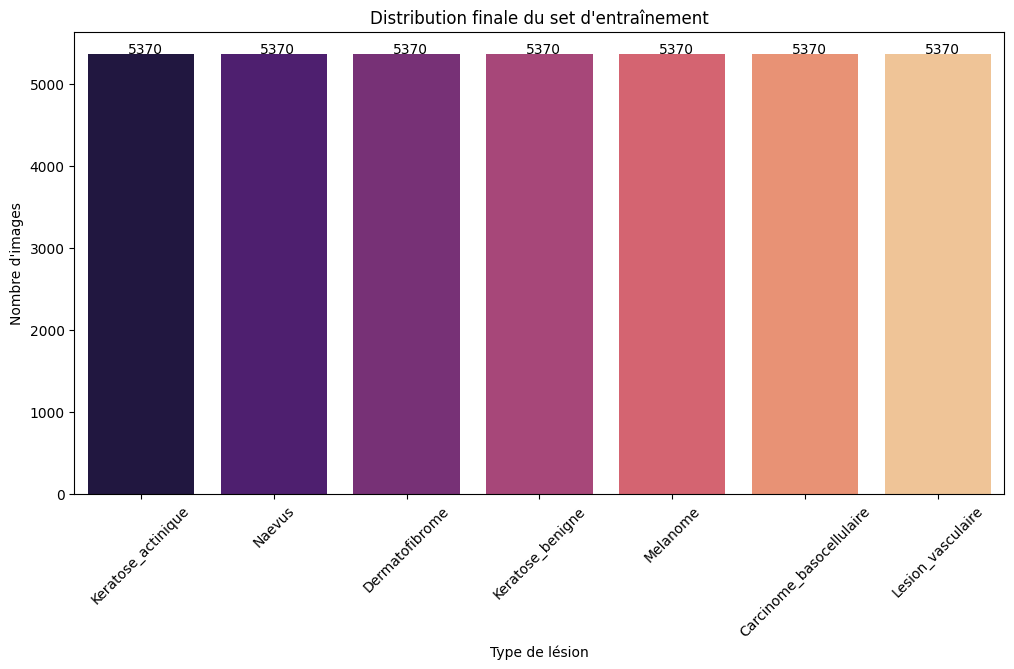

📊 Récapitulatif du nombre d'images par classe (Train) :
label
Keratose_actinique          5370
Naevus                      5370
Dermatofibrome              5370
Keratose_benigne            5370
Melanome                    5370
Carcinome_basocellulaire    5370
Lesion_vasculaire           5370
Name: count, dtype: int64


In [5]:
# Vérification de la distribution
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=train_df_balanced, x='label', palette='magma')

# Ajout des étiquettes de valeur pour prouver l'équilibre parfait
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.3, p.get_height()+10))

plt.xticks(rotation=45)
plt.title("Distribution finale du set d'entraînement")
plt.xlabel("Type de lésion")
plt.ylabel("Nombre d'images")
plt.show()

print("📊 Récapitulatif du nombre d'images par classe (Train) :")
print(train_df_balanced['label'].value_counts())

In [6]:
base_dir = '/content/classifier_data'
if os.path.exists(base_dir): shutil.rmtree(base_dir)

def prepare_yolo_folders(df_data, split_name):
    for _, row in df_data.iterrows():
        dest_dir = os.path.join(base_dir, split_name, row['label'])
        os.makedirs(dest_dir, exist_ok=True)
        shutil.copy(row['path'], os.path.join(dest_dir, os.path.basename(row['path'])))

print("Structuration des dossiers")
prepare_yolo_folders(train_df_balanced, 'train')
prepare_yolo_folders(val_df, 'val')
prepare_yolo_folders(test_df, 'test')
print("Dossiers créées")

Structuration des dossiers
Dossiers créées


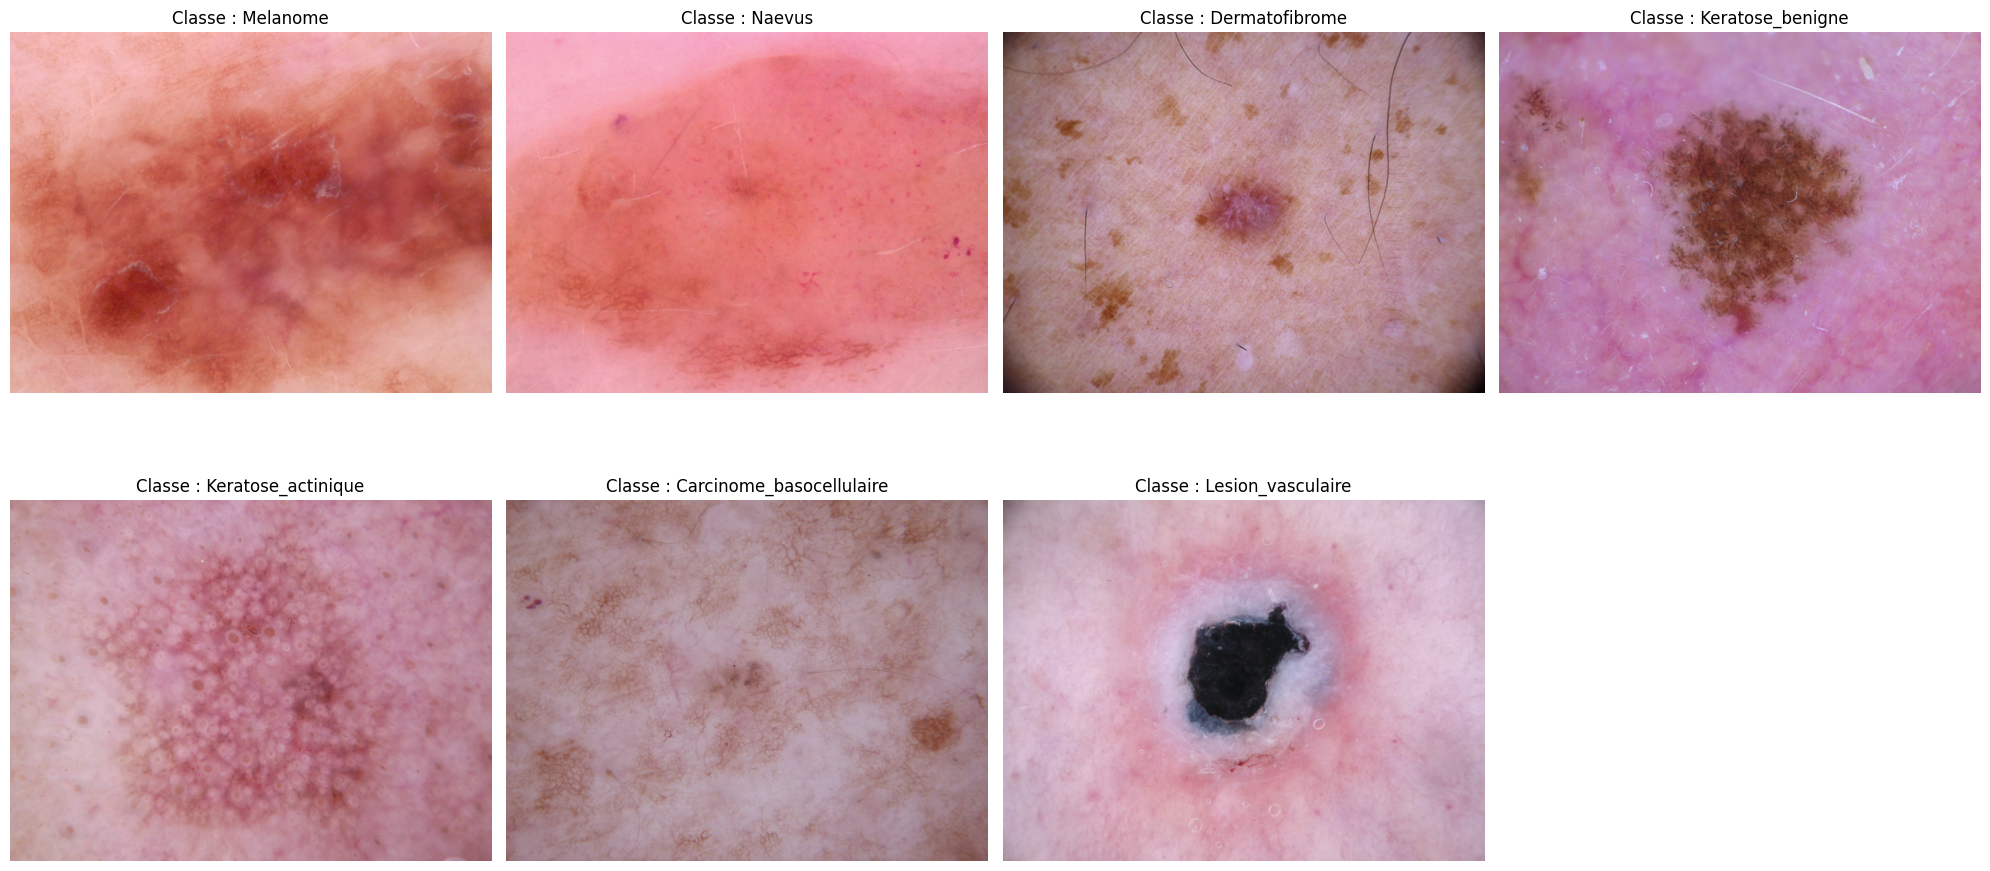

In [7]:
classes = os.listdir(os.path.join(base_dir, 'train'))
plt.figure(figsize=(20, 10))

for i, cls in enumerate(classes):
    cls_path = os.path.join(base_dir, 'train', cls)
    # Choix d'une image au hasard
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    img = plt.imread(img_path)
    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    plt.title(f"Classe : {cls}", fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

# 4. Chargement du modèle et statistique

In [8]:
# Modèle utilisé
model = YOLO('yolov8m-cls.pt')
# Résumé du modèle
print("--- Résumé du Modèle YOLOv8 ---")
model.info()

# Affichage du nombre de paramètres
total_params = sum(p.numel() for p in model.model.parameters())

print(f"\nStatistiques détaillées :")
print(f"Nombre total de paramètres : {total_params:,}")

# Listing des couches
print("\n--- Structure des premières et dernières couches ---")
layers = list(model.model.named_modules())
for name, layer in layers:
    print(f"Nom: {name: <15} | Type: {type(layer).__name__}")

--- Résumé du Modèle YOLOv8 ---
YOLOv8m-cls summary: 80 layers, 17,053,336 parameters, 0 gradients, 42.9 GFLOPs

Statistiques détaillées :
Nombre total de paramètres : 17,053,336

--- Structure des premières et dernières couches ---
Nom:                 | Type: ClassificationModel
Nom: model           | Type: Sequential
Nom: model.0         | Type: Conv
Nom: model.0.conv    | Type: Conv2d
Nom: model.0.bn      | Type: BatchNorm2d
Nom: model.0.act     | Type: SiLU
Nom: model.1         | Type: Conv
Nom: model.1.conv    | Type: Conv2d
Nom: model.1.bn      | Type: BatchNorm2d
Nom: model.2         | Type: C2f
Nom: model.2.cv1     | Type: Conv
Nom: model.2.cv1.conv | Type: Conv2d
Nom: model.2.cv1.bn  | Type: BatchNorm2d
Nom: model.2.cv2     | Type: Conv
Nom: model.2.cv2.conv | Type: Conv2d
Nom: model.2.cv2.bn  | Type: BatchNorm2d
Nom: model.2.m       | Type: ModuleList
Nom: model.2.m.0     | Type: Bottleneck
Nom: model.2.m.0.cv1 | Type: Conv
Nom: model.2.m.0.cv1.conv | Type: Conv2d
Nom: model

# 5. Entraînement du modèle

In [10]:
results = model.train(
    data=base_dir,
    # -- Paramètres pour le rééquilibrage et la modification légère des images dupliquées --
    degrees=15.0,      # Rotation de +/- 15 degrés
    flipud=0.5,        # 50% de chances de retourner l'image verticalement
    fliplr=0.5,        # 50% de chances de retourner l'image horizontalement
    hsv_v=0.4,         # Variation de la luminosité (Value)
    shear=2.0,         # Effet de cisaillement
    perspective=0.001, # Changement de perspective
    freeze=4,          # Nombre de couche du backbone dégeler pour réentraînement
    epochs=130,
    imgsz=224,
    batch=32,          # Nombre d'images vu à chaque batch
    patience=15,       # Nombre d'epoch avant l'arrêt de l'entraînement si pas d'amélioration
    dropout=0.3,
    lr0=0.003,
    optimizer='AdamW',
    name='v1_balanced',
    project='/content/drive/MyDrive/Toubib_AI',
    device=0
)

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/classifier_data, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.3, dynamic=False, embed=None, end2end=None, epochs=130, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=4, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.003, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v1_balanced-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=T

# 6. Affichage des graphiques de résultats

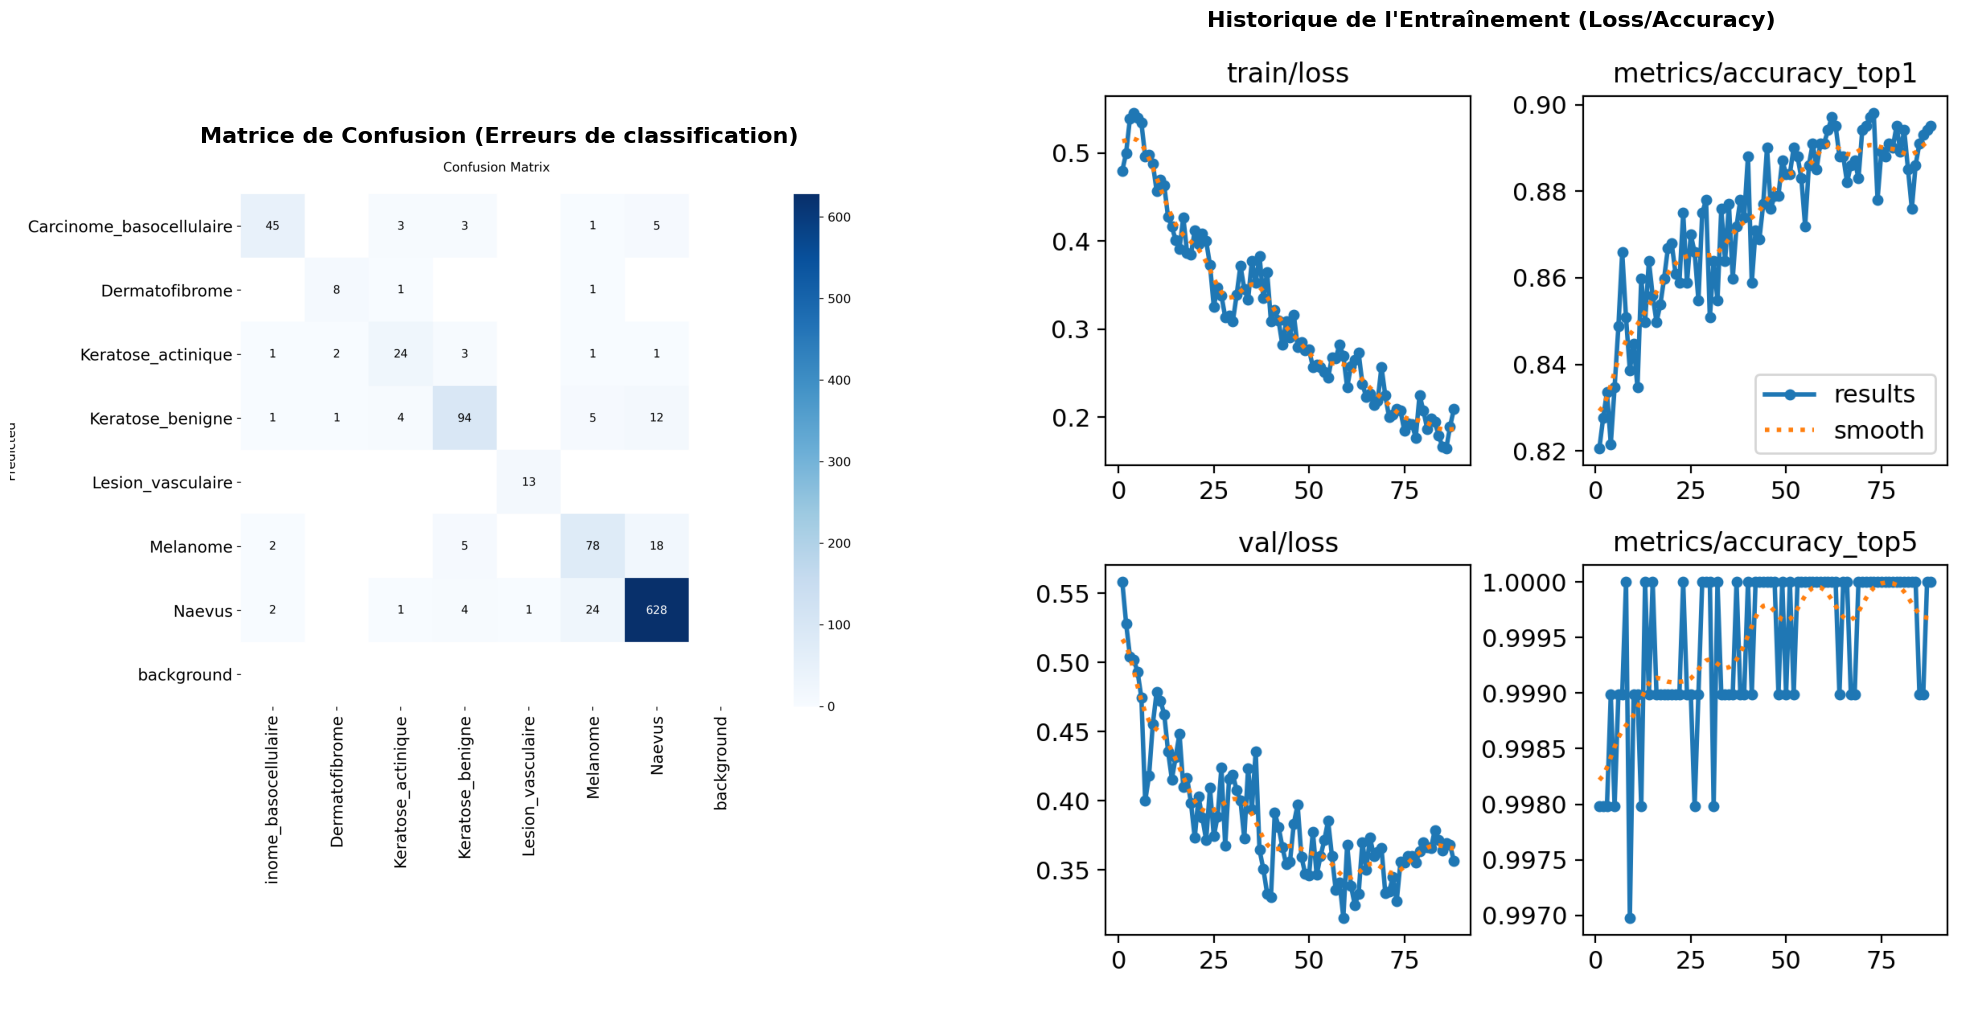

In [12]:
# Récupération des résultats dans le drive:
# /!\ Attention il incrémente le v1_balancedX, vi_balanced-X
results_dir = '/content/drive/MyDrive/Toubib_AI/v1_balanced-4' # <== Ne pas oublié de modifier sinon erreur

# Graphiques à afficher
charts = [
    ('confusion_matrix.png', 'Matrice de Confusion (Erreurs de classification)'),
    ('results.png', 'Historique de l\'Entraînement (Loss/Accuracy)')
]

plt.figure(figsize=(20, 20))

for i, (filename, title) in enumerate(charts):
    path = os.path.join(results_dir, filename)

    if os.path.exists(path):
        plt.subplot(2, 2, i + 1)
        img = mpimg.imread(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(title, fontsize=16, fontweight='bold')
    else:
        print(f"⚠️ Le fichier {filename} n'a pas été trouvé dans {results_dir}")

plt.tight_layout()
plt.show()

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,771,623 parameters, 0 gradients, 41.6 GFLOPs
train: /content/classifier_data/train... found 6018 images in 7 classes ✅ 
val: /content/classifier_data/val... found 992 images in 7 classes ✅ 
test: /content/classifier_data/test... found 1002 images in 7 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3361.5±1047.3 MB/s, size: 234.0 KB)
test: Scanning /content/classifier_data/test... 1002 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1002/1002 3.4Kit/s 0.3s
test: New cache created: /content/classifier_data/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 63/63 32.1it/s 2.0s
                   all      0.877      0.999
Speed: 0.1ms preprocess, 0.9ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val

Précision Top-1 (Test Set) : 87.72%
Dossier des résultats : /content/runs/classi

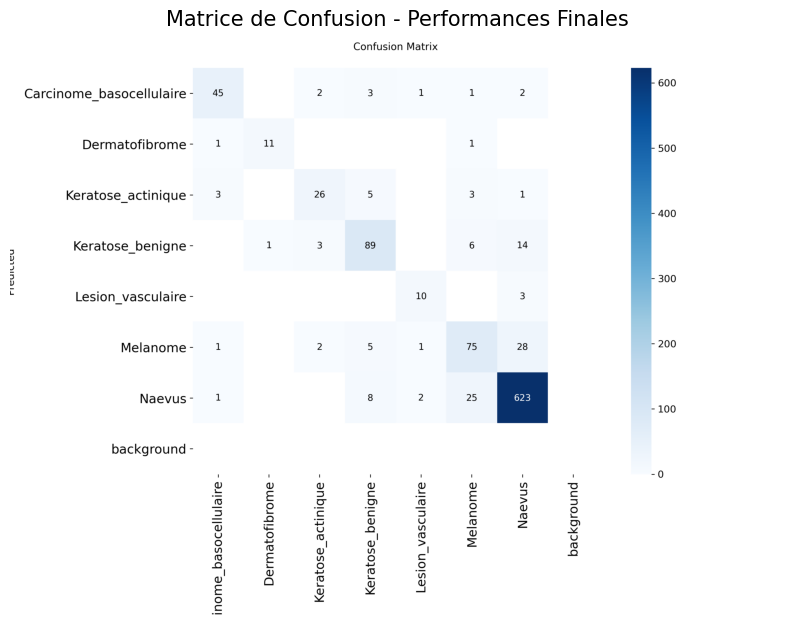

In [13]:
# Enregistrement des résultats dans le drive:
# /!\ Attention il incrémente le v1_balancedX, v1_balanced-X
project_path = '/content/drive/MyDrive/Toubib_AI/v1_balanced-4' # <== Ne pas oublié de modifier sinon erreur
best_model_path = os.path.join(project_path, 'weights/best.pt')

if os.path.exists(best_model_path):
    final_model = YOLO(best_model_path)

    metrics = final_model.val(split='test', save=True)

    print(f"\nPrécision Top-1 (Test Set) : {metrics.top1*100:.2f}%")
    print(f"Dossier des résultats : {metrics.save_dir}")

    result_img = os.path.join(metrics.save_dir, 'confusion_matrix.png')

    if os.path.exists(result_img):
        plt.figure(figsize=(10, 10))
        img = mpimg.imread(result_img)
        plt.imshow(img)
        plt.axis('off')
        plt.title("Matrice de Confusion - Performances Finales", fontsize=15)
        plt.show()
else:
    print(f"Erreur : Modèle introuvable à l'adresse {best_model_path}")

In [14]:
# Exportation vers ONNX
onnx_path = final_model.export(format='onnx')
shutil.copy(onnx_path, '/content/drive/MyDrive/Toubib_AI/toubib_AI_final.onnx')
print(f"Modèle ONNX sauvegardé sur le drive !")

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/drive/MyDrive/Toubib_AI/v1_balanced-4/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 7) (30.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 184ms
Prepared 4 packages in 3.12s
Installed 4 packages in 335ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 4.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 5.7s, saved as 